In [25]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
using LinearAlgebra
using Printf
import Plots as plt


  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`


In [26]:
fixed_solvers = Dict(
    "Forward Euler"         => HD.ForwardEuler(),
    "Backward Euler"        => HD.BackwardEuler(),
    "Modified Trapezoid"    => HD.ModifiedTrap(),
    "Modified Midpoint"     => HD.ModifiedMidpoint(),
    "Richardson Extrap."    => HD.RichardsonExtrapolation(),
    "RK4"                   => HD.RK4(),
    "Adams-Bashforth 2"     => HD.AdamsBashforth2(),
    "Adams-Bashforth 3"     => HD.AdamsBashforth3(),
    "BDF2"                  => HD.BDF2()
);

In [27]:
adaptive_solvers = Dict(
    "Adaptive ABM2" => HD.AdaptiveABM2(),
    "Adaptive ABM3" => HD.AdaptiveABM3(),
    "RK23"          => HD.RK23(),
    "RK45"          => HD.RK45()
);

In [28]:
custom_tols = Dict(
    "RK23"          => 10.0 .^ range(-2, -8, length=8),
    "RK45"          => 10.0 .^ range(-4, -9, length=10),
    "Adaptive ABM2" => 10.0 .^ range(-2, -8, length=8),
    "Adaptive ABM3" => 10.0 .^ range(-3, -7, length=8)
)

dts_fixed = 2.0 .^ (-(2:10));

In [29]:
function sys_general(; xC=0.0, xH=1.0)
    f_therm(u, t) = [u[2], 0.0]  # dx/dt = y, dy/dt = 0
    h_therm(u) = u[2] > 0 ? (u[1] - xH) : (xC - u[1])
    Δ_therm(u) = [u[1], -u[2]]
    
    # FIX: Setting direction=1 specifically looks for positive guard crossings.
    # This completely bypasses the `abs(guard) > tol` Zeno termination bug 
    # in `take_step_general!` which was causing the solvers to abort early.
    return HD.GeneralSystem(f_therm, h_therm, Δ_therm; direction=1)
end

function exact_general(t; x0=0.1, xC=0.0, xH=1.0)
    t1 = xH - x0 # Time to hit the first guard (0.9)
    if t < t1
        return [x0 + t, 1.0]
    end
    
    t_after = t - t1
    period = 2.0 * (xH - xC)
    t_mod = mod(t_after, period)
    half = xH - xC
    
    if t_mod < half
        return [xH - t_mod, -1.0] # Cooling phase
    else
        return [xC + (t_mod - half), 1.0] # Heating phase
    end
end

exact_general (generic function with 1 method)

In [30]:
#Filippov System
sys_filippov() = HD.FilippovSystem(x -> [-x[1], -x[2]], x -> [0.0, 0.0], x -> x[1] + 100.0, x -> [1.0, 0.0])
exact_filippov(t) = [exp(-t), exp(-t)]

exact_filippov (generic function with 1 method)

In [31]:
#Mechanical System
sys_mechanical() = HD.MechanicalSystem(q -> [1.0 0.0; 0.0 1.0], q -> 0.5 * (q[1]^2 + q[2]^2); guard=q -> q[1] + 100.0, normal=q -> [1.0, 0.0], e=1.0)
exact_mechanical(t) = [cos(t), sin(t), -sin(t), cos(t)]

exact_mechanical (generic function with 1 method)

In [32]:
#NH System
sys_nonholonomic() = HD.NonholonomicSystem(q -> [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 1.0] .* one(eltype(q)), q -> 0.5 * (q[1]^2 + q[2]^2); A=q -> [-sin(q[3]) cos(q[3]) 0.0], guard=q -> q[1] + 100.0, normal=q -> [1.0, 0.0, 0.0], e=1.0)
exact_nonholonomic(t) = [cos(t), 0.0, 0.0, -sin(t), 0.0, 0.0]

exact_nonholonomic (generic function with 1 method)

In [33]:
#Linear System
sys_linear() = HD.LinearSystem([-1.0 0.0; 0.0 -2.0], [1.0, 0.0], [1.0 0.0; 0.0 1.0])
exact_linear(t) = [exp(-t), exp(-2.0*t)]

exact_linear (generic function with 1 method)

In [34]:
sys_affine() = HD.AffineSystem([-1.0 0.0; 0.0 -1.0], [2.0, 3.0], [1.0, 0.0], 100.0, [1.0 0.0; 0.0 1.0], [0.0, 0.0])
exact_affine(t) = [2.0 - exp(-t), 3.0 - 2.0*exp(-t)]

exact_affine (generic function with 1 method)

In [35]:
systems = Dict(
    "General"      => (sys=sys_general,     x0=[0.0, 1.0],          tspan=(0.0, 1.0), exact=exact_general),
    "Filippov"     => (sys=sys_filippov,    x0=[1.0, 1.0],          tspan=(0.0, 2.0), exact=exact_filippov),
    "Mechanical"   => (sys=sys_mechanical,  x0=[1.0, 0.0, 0.0, 1.0], tspan=(0.0, 1.0), exact=exact_mechanical),
    "Nonholonomic" => (sys=sys_nonholonomic,x0=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], tspan=(0.0, 1.0), exact=exact_nonholonomic),
    "Linear"       => (sys=sys_linear,      x0=[1.0, 1.0],          tspan=(0.0, 2.0), exact=exact_linear),
    "Affine"       => (sys=sys_affine,      x0=[1.0, 1.0],          tspan=(0.0, 2.0), exact=exact_affine)
)

Dict{String, NamedTuple{(:sys, :x0, :tspan, :exact)}} with 6 entries:
  "Affine"       => (sys = sys_affine, x0 = [1.0, 1.0], tspan = (0.0, 2.0), exa…
  "General"      => (sys = sys_general, x0 = [0.0, 1.0], tspan = (0.0, 1.0), ex…
  "Mechanical"   => (sys = sys_mechanical, x0 = [1.0, 0.0, 0.0, 1.0], tspan = (…
  "Nonholonomic" => (sys = sys_nonholonomic, x0 = [1.0, 0.0, 0.0, 0.0, 0.0, 0.0…
  "Filippov"     => (sys = sys_filippov, x0 = [1.0, 1.0], tspan = (0.0, 2.0), e…
  "Linear"       => (sys = sys_linear, x0 = [1.0, 1.0], tspan = (0.0, 2.0), exa…

In [36]:
function run_fixed_benchmarks(systems, solvers, dts)
    println(" FIXED STEP SOLVERS BENCHMARK (Error vs. Δt)")

    for (sys_name, spec) in systems
        plt.plot(title="Fixed Solvers: $sys_name", xlabel="Step Size (Δt)", ylabel="Terminal Error", 
                 xscale=:log10, yscale=:log10, legend=:outerright, grid=true)
        
        println("\nSystem: $sys_name")
        println(rpad("Solver", 25), " | ", "Estimated Order")

        for (solver_name, solver) in solvers
            prob = HD.prob(spec.sys(), spec.x0, spec.tspan)
            tf = spec.tspan[end]
            errors = zeros(length(dts))

            for (i, dt) in enumerate(dts)
                sol = HD.solve(prob, solver; dt_initial = dt)
                errors[i] = norm(sol.x[end] - spec.exact(tf))
            end

            # Least-squares fit for order estimate
            logh = log10.(dts)
            loge = log10.(errors)
            p = hcat(logh, ones(length(logh))) \ loge
            order = p[1]

            println(rpad(solver_name, 25), " → ", round(order, digits=4))
            plt.plot!(dts, errors, marker=:circle, label="$solver_name (p≈$(round(order, digits=2)))")
        end
        display(plt.current())
    end
end

run_fixed_benchmarks (generic function with 1 method)

In [37]:
function run_adaptive_benchmarks(systems, solvers, tols_dict)
    println(" ADAPTIVE SOLVERS BENCHMARK (Error vs. Tolerance)")

    for (sys_name, spec) in systems
        plt.plot(title="Adaptive Solvers: $sys_name", xlabel="Tolerance (tol)", ylabel="Terminal Error", xscale=:log10, yscale=:log10, legend=:outerright, grid=true)

        println("\nSystem: $sys_name")
        println(rpad("Solver", 25), " | ", "Log-Slope Error/Tol")

        for (solver_name, solver) in solvers
            prob = HD.prob(spec.sys(), spec.x0, spec.tspan)
            tf = spec.tspan[end]
            tols = tols_dict[solver_name]
            errors = zeros(length(tols))

            for (i, tol) in enumerate(tols)
                sol = HD.solve(prob, solver; tol = tol)
                errors[i] = norm(sol.x[end] - spec.exact(tf))
            end

            # Estimate slope against tolerance
            logtol = log10.(tols)
            loge = log10.(errors)
            p = hcat(logtol, ones(length(logtol))) \ loge
            slope = p[1]

            println(rpad(solver_name, 25), " → ", round(slope, digits=4))
            plt.plot!(tols, errors, marker=:square, label="$solver_name")
        end
        display(plt.current())
    end
end

run_adaptive_benchmarks (generic function with 1 method)

The fixed-step solvers operate with a constant step size $\Delta t$. For a solver of order $p$, the Global Truncation Error (GTE) is expected to scale as: $$\varepsilon \approx C\cdot \Delta t^p.$$ By taking the log of both sides, we obtain the linear relationship: $$\log(\varepsilon)\approx p\cdot\log(\Delta t)+\log(C).$$ On a log-log plot (like we have below), the slope of the line is exactly equal to the order $p$ of the solver. We verify our implementation by computing the slope of the error curve to ensure it matches the theoretical order (e.g., $p=1$ for Euler, $p=4$ for RK4).

Adaptive solvers do not maintain a constant $\Delta t$; instead, they adjust step sizes to maintain a local error tolerance $\tau $. The relationship between GTE ($\varepsilon$) and the tolerance ($\tau) follows from the power law: $$\varepsilon \approx \tau ^{\frac{p}{p+1}}.$$

It is also worth noting some of the strange behavior you will see in the graphs below for the adaptive solvers. Some seem a little rough instead of nice and smooth and that can be for a number of reasons. As adaptive solvers have non-fixed step size its possible to get a 'lucky' step which makes it much more/less accurate then expected.

You will also notice General Systems have a slope of 0.0. This is simply because of the example chosen (by request of our superiors) and this will be left as such. 

 FIXED STEP SOLVERS BENCHMARK (Error vs. Δt)

System: Affine
Solver                    | Estimated Order
Adams-Bashforth 3         → 2.9743
RK4                       → 3.9659
Backward Euler            → 0.9939
BDF2                      → 1.9748
Modified Midpoint         → 2.0286
Forward Euler             → 1.0059
Modified Trapezoid        → 2.0286
Richardson Extrap.        → 3.0216
Adams-Bashforth 2         → 1.9799

System: General
Solver                    | Estimated Order
Adams-Bashforth 3         → -0.0
RK4                       → -0.0
Backward Euler            → -0.0
BDF2                      → -0.0
Modified Midpoint         → -0.0
Forward Euler             → -0.0
Modified Trapezoid        → -0.0
Richardson Extrap.        → -0.0
Adams-Bashforth 2         → -0.0

System: Mechanical
Solver                    | Estimated Order
Adams-Bashforth 3         → 2.8214
RK4                       → 4.0046
Backward Euler            → 0.9892
BDF2                      → 1.8701
Modified Midpoint 

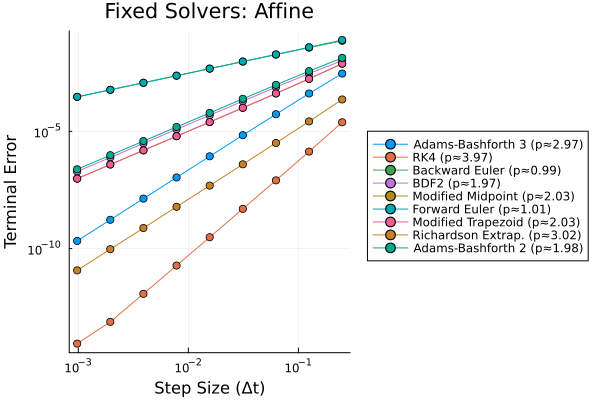

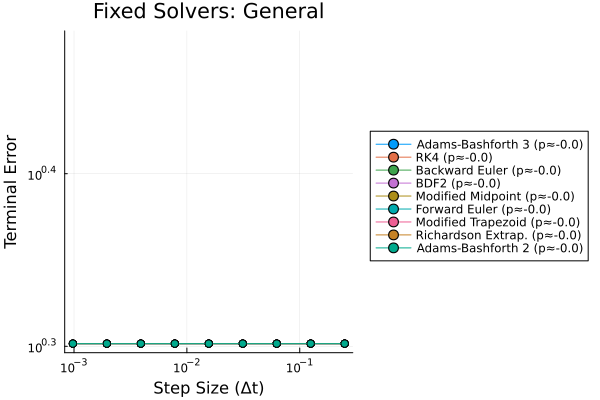

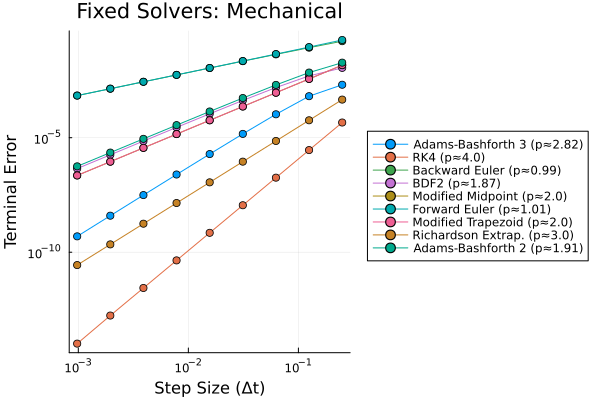

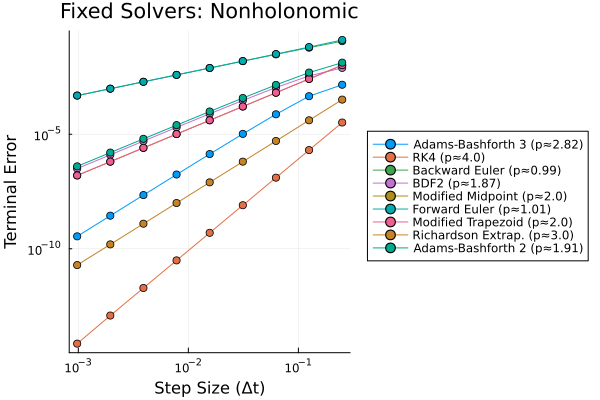

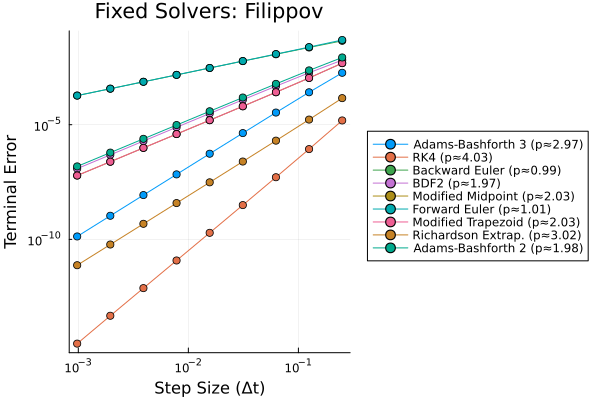

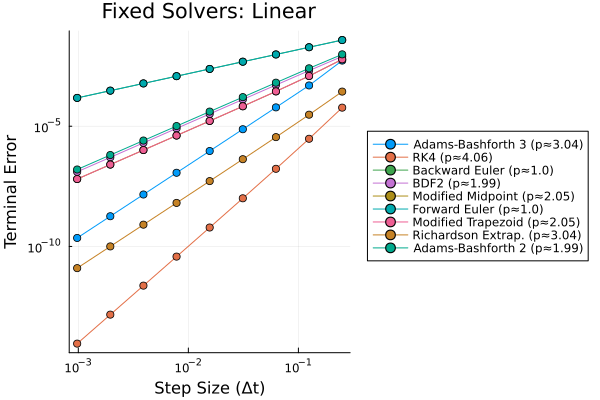

In [39]:
run_fixed_benchmarks(systems, fixed_solvers, dts_fixed)

 ADAPTIVE SOLVERS BENCHMARK (Error vs. Tolerance)

System: Affine
Solver                    | Log-Slope Error/Tol
RK23                      → 0.6525
RK45                      → 0.4995
Adaptive ABM2             → 0.9076
Adaptive ABM3             → 1.4437

System: General
Solver                    | Log-Slope Error/Tol
RK23                      → -0.0
RK45                      → -0.0
Adaptive ABM2             → -0.0
Adaptive ABM3             → -0.0

System: Mechanical
Solver                    | Log-Slope Error/Tol
RK23                      → 0.6489
RK45                      → 0.5001
Adaptive ABM2             → 0.8899
Adaptive ABM3             → 1.3854

System: Nonholonomic
Solver                    | Log-Slope Error/Tol
RK23                      → 0.641
RK45                      → 0.4999
Adaptive ABM2             → 0.8899
Adaptive ABM3             → 1.3854

System: Filippov
Solver                    | Log-Slope Error/Tol
RK23                      → 0.6561
RK45                      → 0.4

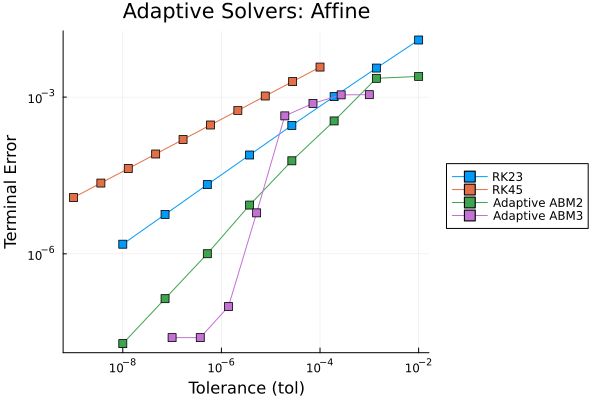

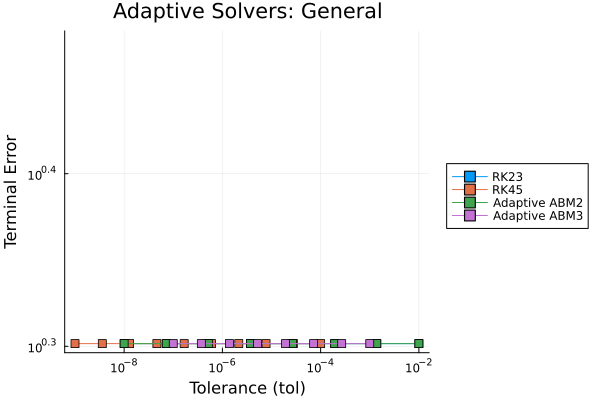

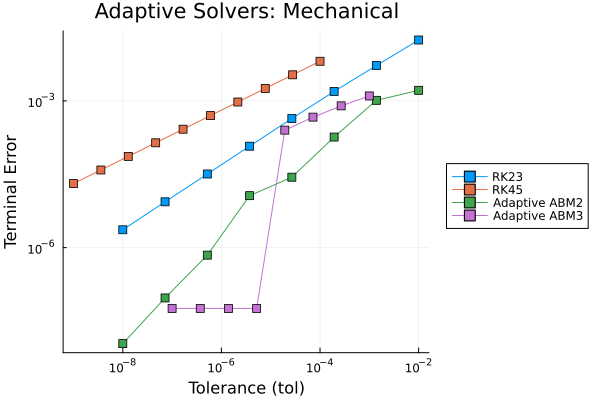

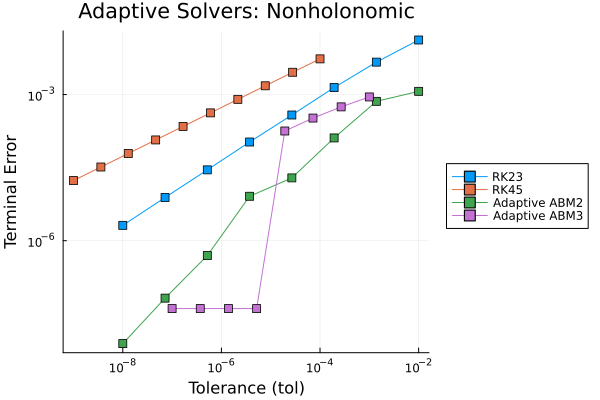

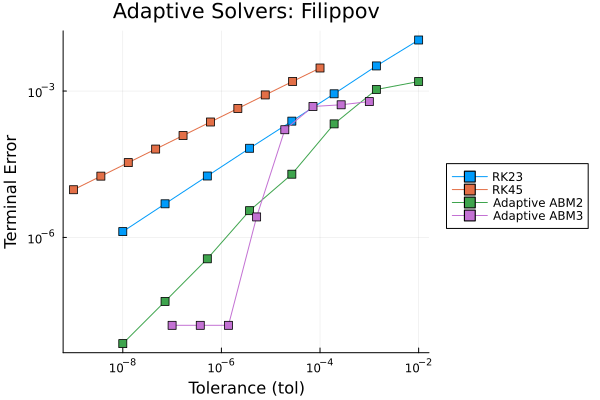

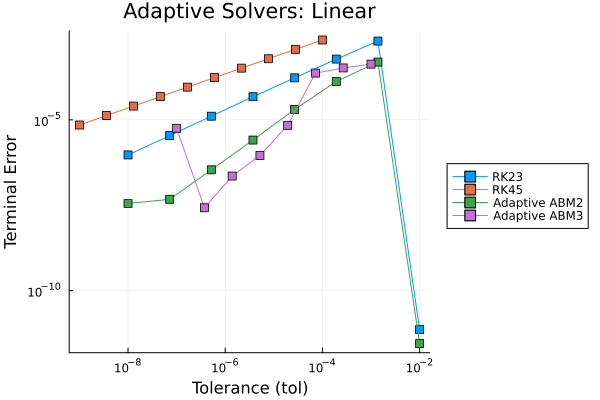

┌ Info: Time to end of simulation below minimum time step. Ending simulation at t = 1.999999117524744
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Linear_Affine.jl:454
┌ Warning: LMM Step size has decreased below 1e-6
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\ODE_Solvers\Linear_Multistep_Methods\Adaptive_LMM_Steps.jl:112


In [40]:
run_adaptive_benchmarks(systems, adaptive_solvers, custom_tols)